Dataset shape: (12000, 33)

Missing values:
 family_history    7176
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 12000 non-null  int64  
 1   age                        12000 non-null  int64  
 2   sex                        12000 non-null  object 
 3   bmi                        12000 non-null  float64
 4   smoking_status             12000 non-null  object 
 5   pack_years                 12000 non-null  float64
 6   pm25_exposure              12000 non-null  float64
 7   occupation                 12000 non-null  object 
 8   family_history             4824 non-null   object 
 9   cough                      12000 non-null  int64  
 10  dyspnea                    12000 non-null  int64  
 11  wheeze                     12000 non-null  int64  
 12  chest_pain           

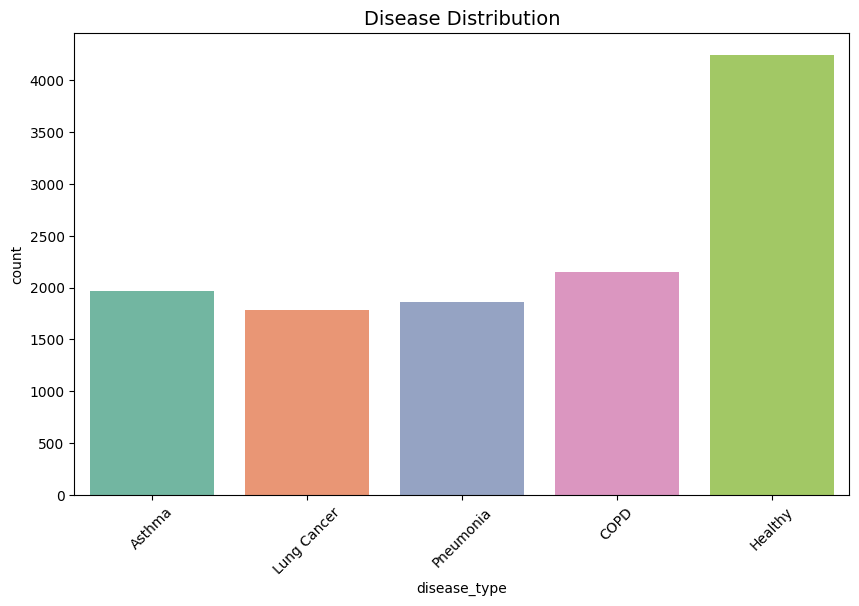


Key statistics:
         patient_id           age           bmi    pack_years  pm25_exposure  \
count  12000.00000  12000.000000  12000.000000  12000.000000   12000.000000   
mean    6000.50000     58.070833     27.008608     14.767758      15.114308   
std     3464.24595     14.741634      4.961936     14.848183       6.689190   
min        1.00000     18.000000     16.000000      0.000000       3.000000   
25%     3000.75000     48.000000     23.500000      2.700000      10.300000   
50%     6000.50000     58.000000     27.000000     10.300000      15.000000   
75%     9000.25000     68.000000     30.400000     22.800000      19.700000   
max    12000.00000     90.000000     45.600000     81.800000      41.300000   

              cough       dyspnea        wheeze    chest_pain         fever  \
count  12000.000000  12000.000000  12000.000000  12000.000000  12000.000000   
mean       0.417333      0.397250      0.246750      0.138083      0.167000   
std        0.493139      0.489349

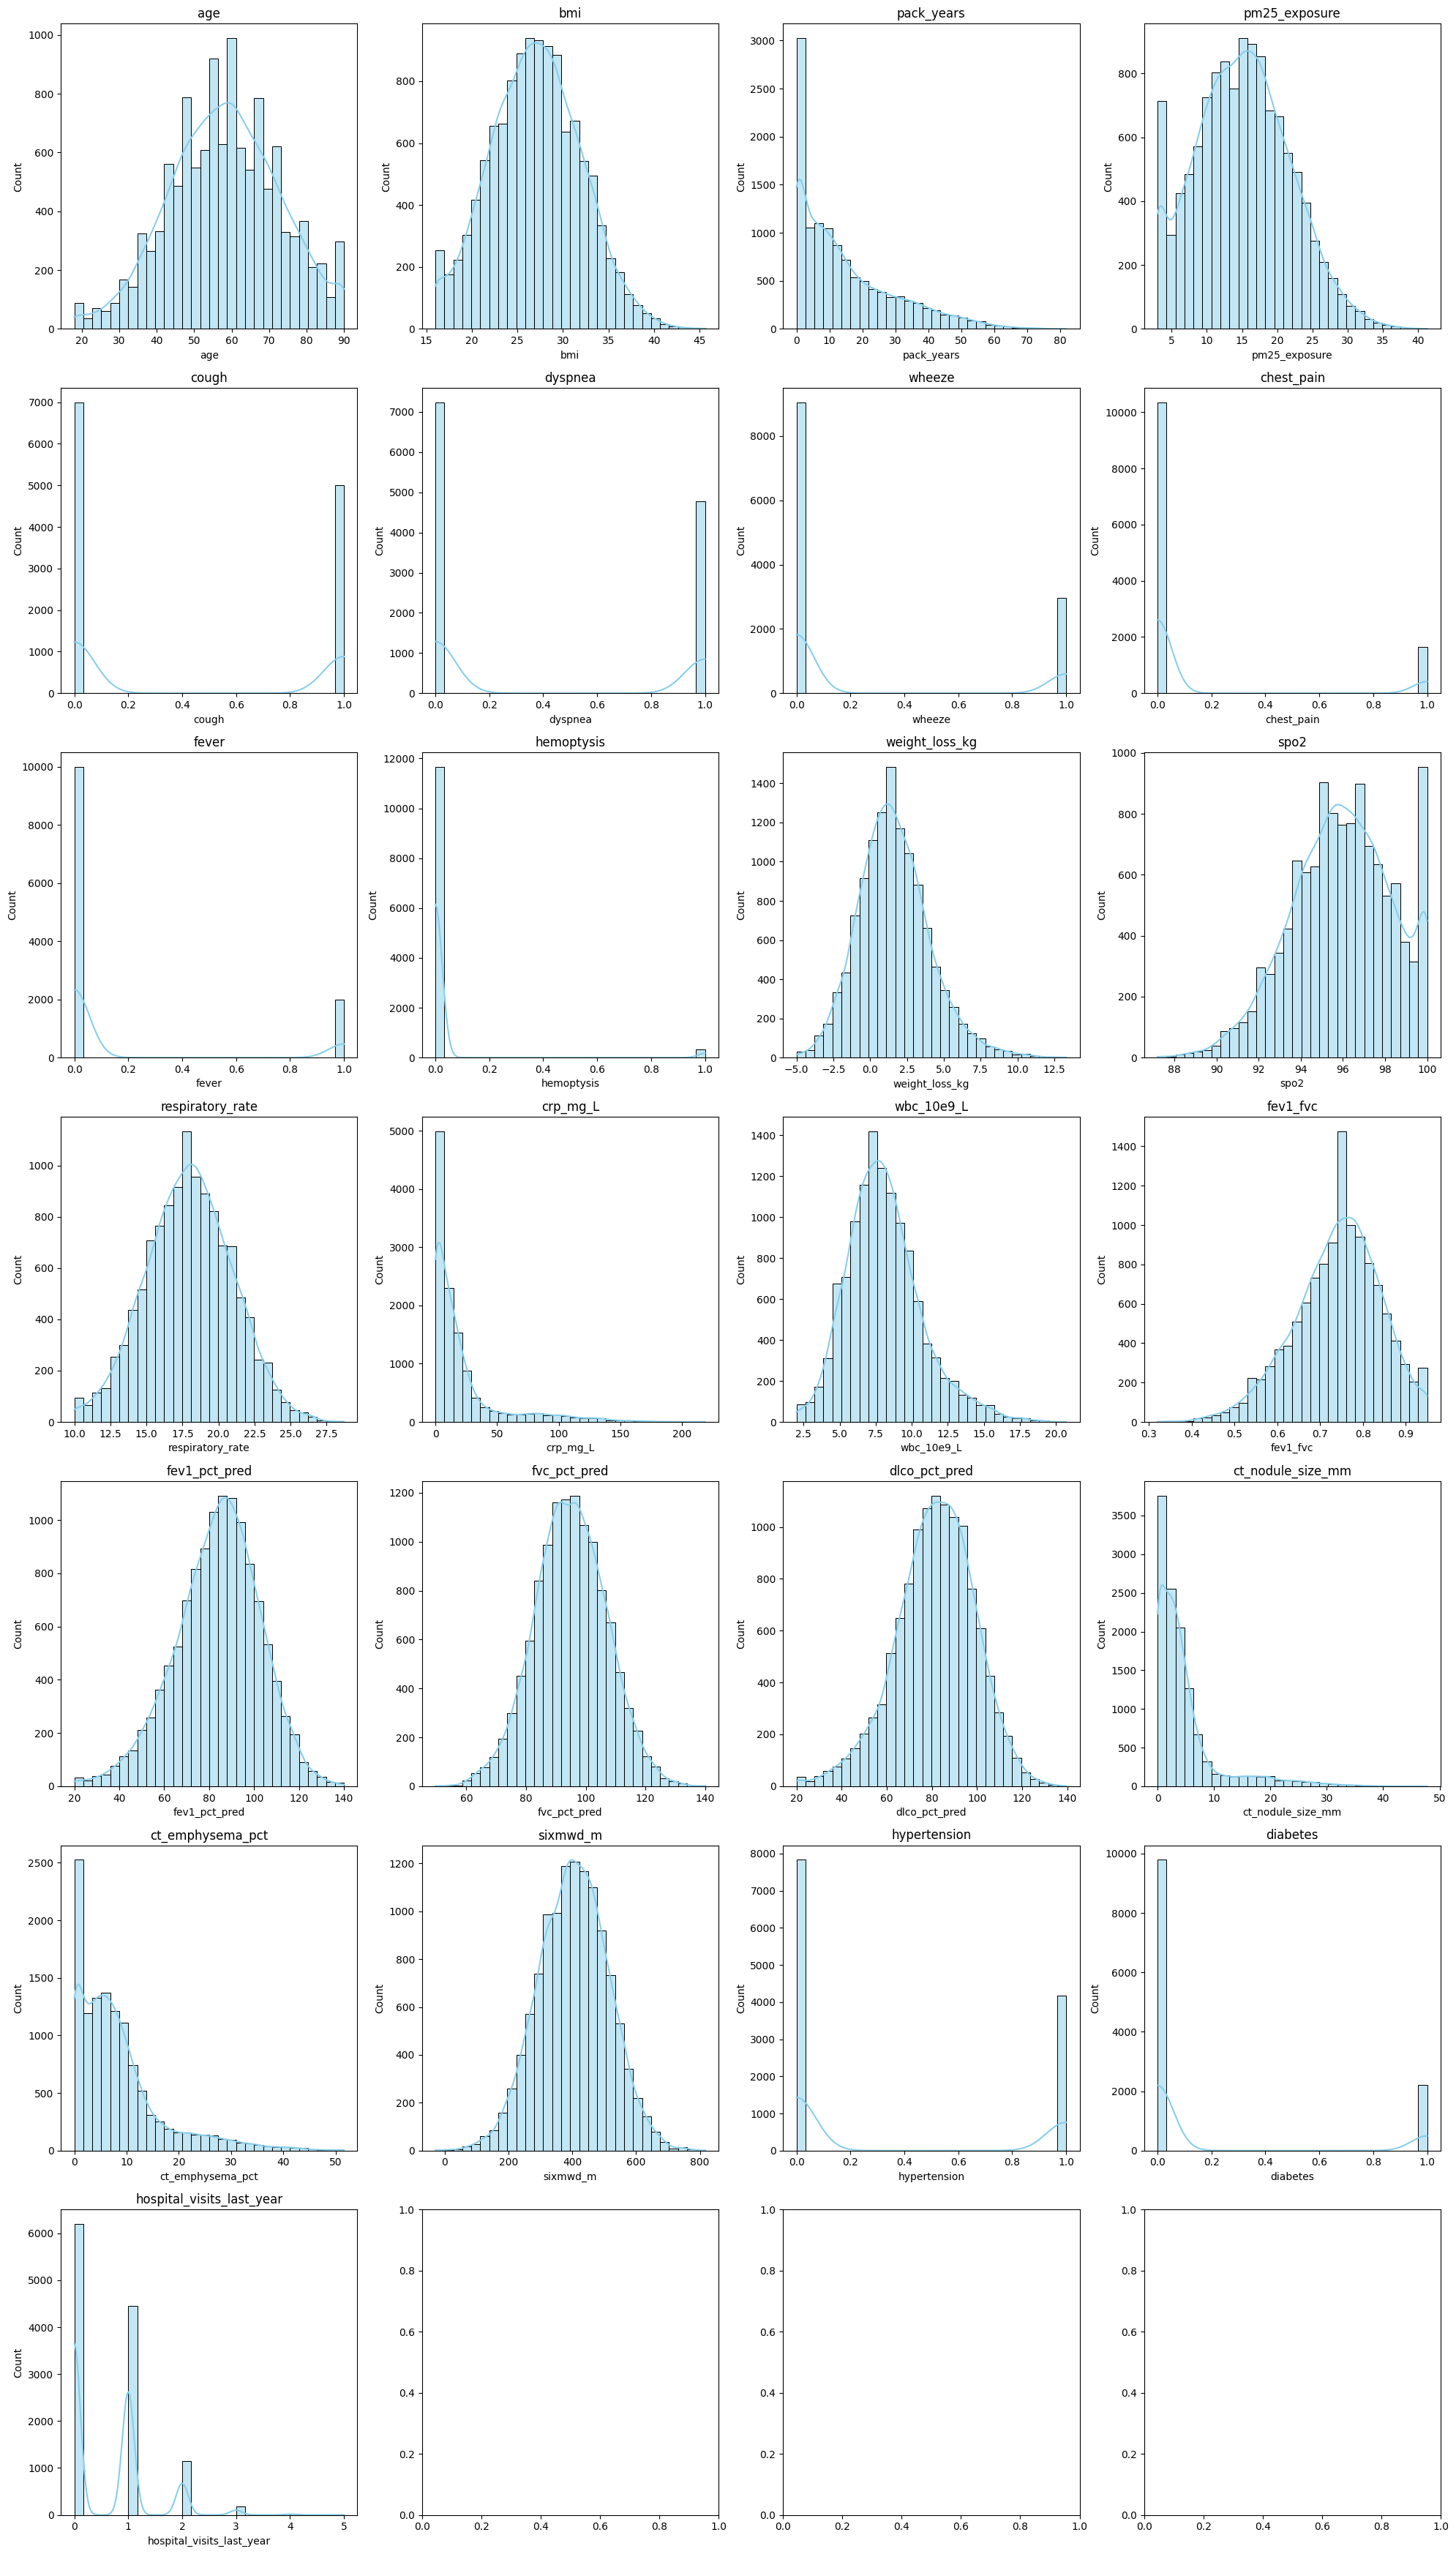

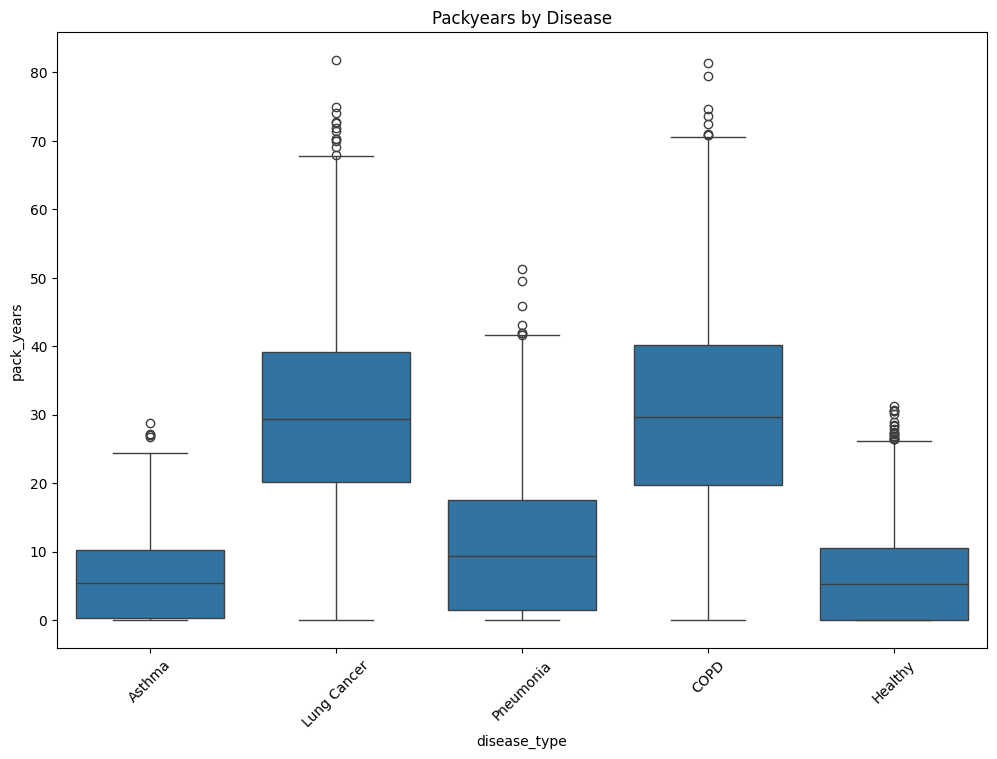


Top 10 features correlated with target:
 target_num           1.000000
crp_mg_L             0.592178
fever                0.453563
wbc_10e9_L           0.388916
fev1_fvc             0.372064
wheeze               0.360624
fev1_pct_pred        0.338662
ct_nodule_size_mm    0.242620
ct_emphysema_pct     0.242099
dlco_pct_pred        0.167489
Name: target_num, dtype: float64


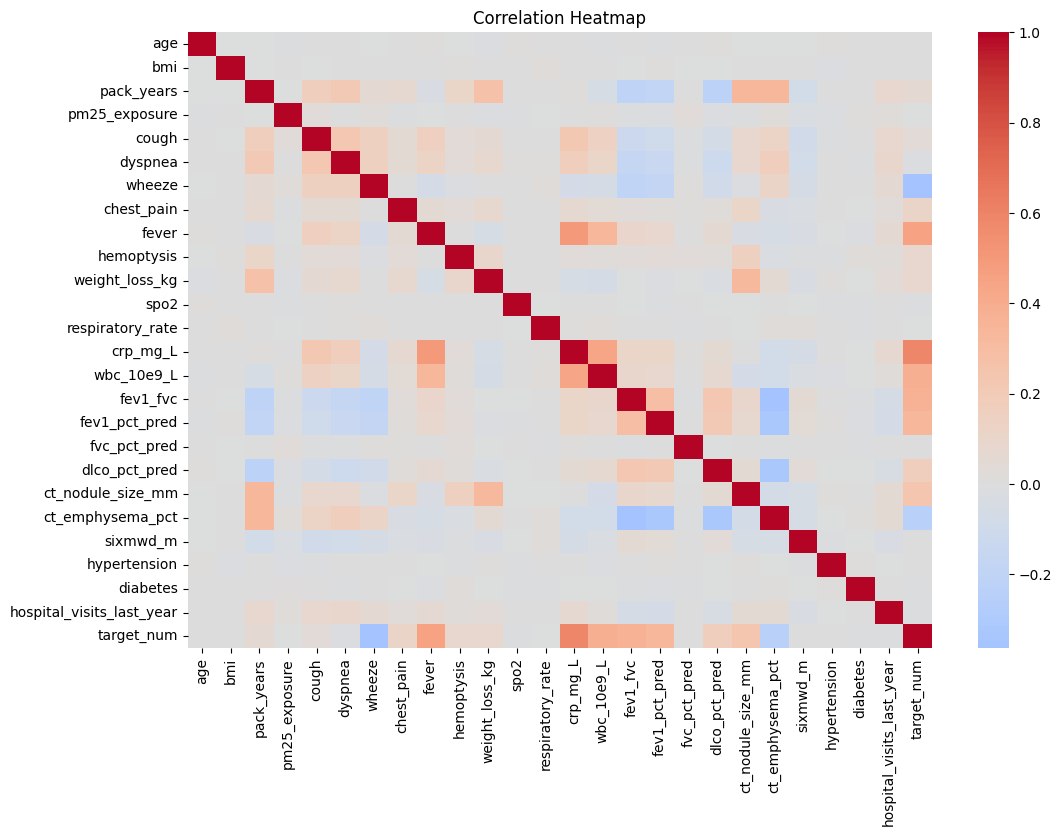

In [33]:
# ===== TASK 1: EXPLORATORY DATA ANALYSIS =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("lung_disease_v1.csv")
target_col = "disease_type"

print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum()>0])
print(df.info())

# 1.1 Target distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x=target_col, palette='Set2')
plt.title('Disease Distribution', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 1.2 Descriptive statistics + key distributions
print("\nKey statistics:\n", df.describe())

# 1.3 All numeric histograms
numeric_cols = df.select_dtypes(include=['int64','float64']).drop(columns=['patient_id']).columns
n_rows = (len(numeric_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# 1.4 Disease-specific trends and correlations
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x=target_col, y='pack_years')
plt.title('Packyears by Disease')
plt.xticks(rotation=45)
plt.show()

le = LabelEncoder()
df['target_num'] = le.fit_transform(df[target_col])
numeric_cols_for_corr = numeric_cols.tolist() + ['target_num']
corr_target = df[numeric_cols_for_corr].corr()['target_num'].abs().sort_values(ascending=False)
print("\nTop 10 features correlated with target:\n", corr_target.head(10))

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols_for_corr].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [35]:
# ===== TASK 2: DATA PREPARATION =====

# 2.1 Clean data
df_clean = df.drop(columns=['patient_id', 'family_history']).copy()
df_clean['sixmwd_m'] = df_clean['sixmwd_m'].clip(lower=0)  # Fix outliers
df_clean['bmi'] = pd.to_numeric(df_clean['bmi'], errors='coerce').fillna(df_clean['bmi'].median())

print("\n=== BEFORE PREPROCESSING ===")
print("Dataset shape:", df_clean.shape)
print("Missing values total:", df_clean.isnull().sum().sum())
print("sixmwd_m range:", df_clean['sixmwd_m'].min(), df_clean['sixmwd_m'].max())
print("\nRaw sample (first 3 rows, first 5 columns):")
print(df_clean.iloc[:3, :5])

# 2.2 Define features
X = df_clean.drop(columns=[target_col, 'target_num'])
y = df_clean[target_col]
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nFeatures: {len(numeric_features)} numeric, {len(categorical_features)} categorical")

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} samples")

# 2.3 Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# BEFORE/AFTER VERIFICATION
print("\n" + "="*60)
print("BEFORE vs AFTER PREPROCESSING DEMONSTRATION")
print("="*60)

# BEFORE: Raw sample
print("\n BEFORE (Raw Data)")
print(X_train.head(3)[list(X_train.columns[:5])].round(2))

X_sample_transformed = preprocessor.fit_transform(X_train.head(5))
feature_names_out = preprocessor.get_feature_names_out()

print("\n AFTER (Transformed Data):")
print(f"Shape changed: ({X_train.shape[1]}) → ({X_sample_transformed.shape[1]})")
print(f"Features expanded: {len(numeric_features)} + {len(categorical_features)} → {len(feature_names_out)}")

# Show first few transformed features
df_after_sample = pd.DataFrame(
    X_sample_transformed[:3, :12],
    columns=feature_names_out[:12]
).round(3)
print("\nSample transformed data (first 3 rows, first 12 features):")
print(df_after_sample)


=== BEFORE PREPROCESSING ===
Dataset shape: (12000, 32)
Missing values total: 0
sixmwd_m range: 0 816

Raw sample (first 3 rows, first 5 columns):
   age     sex   bmi smoking_status  pack_years
0   49    Male  20.1          Never        21.0
1   61  Female  28.4        Current        34.1
2   70    Male  22.2        Current        15.7

Features: 25 numeric, 5 categorical
Train/Test split: 9600 / 2400 samples

BEFORE vs AFTER PREPROCESSING DEMONSTRATION

 BEFORE (Raw Data)
       age     sex   bmi smoking_status  pack_years
10029   54  Female  27.0        Current        15.2
7857    56    Male  22.7        Current        12.2
10131   72  Female  20.2          Never        18.8

 AFTER (Transformed Data):
Shape changed: (30) → (39)
Features expanded: 25 + 5 → 39

Sample transformed data (first 3 rows, first 12 features):
   num__age  num__bmi  num__pack_years  num__pm25_exposure  num__cough  \
0     -0.50     0.747           -0.568               0.729        -0.5   
1     -0.25    -0.

In [15]:
# ===== TASK 3: MODEL TRAINING =====

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000), # Baseline linear model
    'SVM': SVC(probability=True), # High-dimensional boundary classifier
    'Decision Tree': DecisionTreeClassifier(), # Direct logical interpretability
    'Random Forest': RandomForestClassifier(random_state=42), # Robust ensemble to reduce variance
    'KNN': KNeighborsClassifier() # Instance-based similarity learner
}

print("\nDEFAULT HYPERPARAMETERS SUMMARY:")
hyper_summary = []
for name, clf in models.items():
    params = clf.get_params()
    if name == 'Logistic Regression':
        hyper_summary.append(f"{name}: C={params['C']}, penalty={params['penalty']}")
    elif name == 'SVM':
        hyper_summary.append(f"{name}: C={params['C']}, kernel={params['kernel']}")
    elif name == 'Random Forest':
        hyper_summary.append(f"{name}: n_estimators={params['n_estimators']}, max_features={params['max_features']}")
    elif name == 'KNN':
        hyper_summary.append(f"{name}: n_neighbors={params['n_neighbors']}")
    else:
        hyper_summary.append(f"{name}: default settings")

    for param in hyper_summary[-1].split(', '):
        print(f"  {param}")


DEFAULT HYPERPARAMETERS SUMMARY:
  Logistic Regression: C=1.0
  penalty=l2
  SVM: C=1.0
  kernel=rbf
  Decision Tree: default settings
  Random Forest: n_estimators=100
  max_features=sqrt
  KNN: n_neighbors=5



TRAINING AND EVALUATING 5 MODELS

Logistic Regression Results:
              precision    recall  f1-score   support

      Asthma       0.89      0.81      0.85       394
        COPD       0.99      0.97      0.98       429
     Healthy       0.91      0.96      0.94       849
 Lung Cancer       0.99      0.97      0.98       356
   Pneumonia       0.98      0.99      0.99       372

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.94      0.94      0.94      2400


SVM Results:
              precision    recall  f1-score   support

      Asthma       0.86      0.80      0.83       394
        COPD       0.98      0.95      0.97       429
     Healthy       0.91      0.97      0.94       849
 Lung Cancer       0.99      0.96      0.97       356
   Pneumonia       0.99      0.98      0.99       372

    accuracy                           0.94      2400
   macro avg       0.95      0.93      0.94      2400

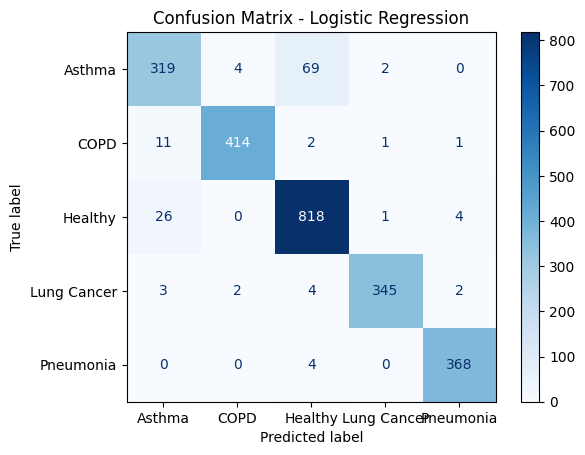

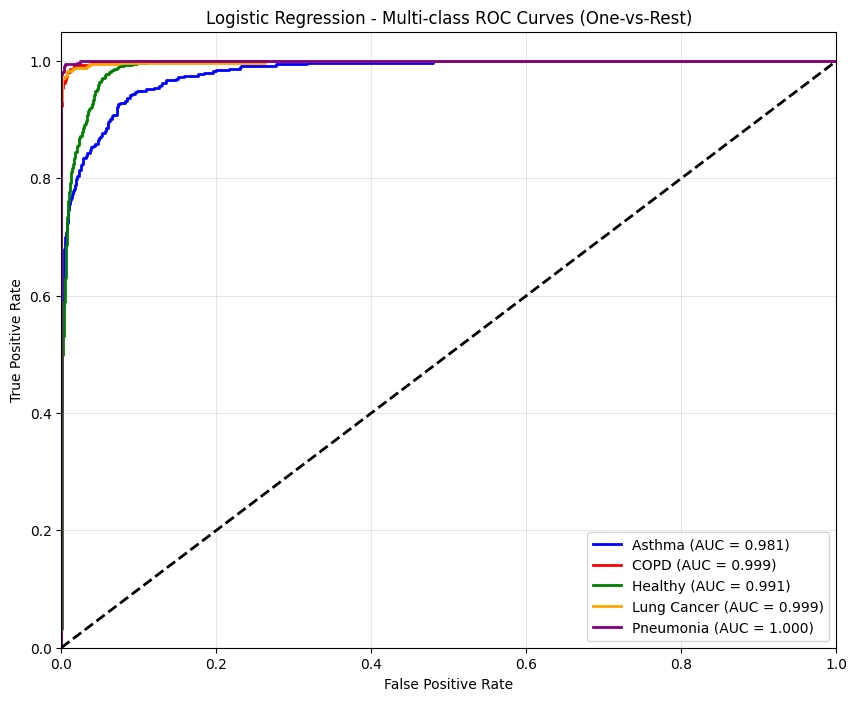


Tuning Random Forest...
 Best RF params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
 Tuned CV F1: 0.945
Generating publication-quality SHAP analysis...


<Figure size 1600x1200 with 0 Axes>

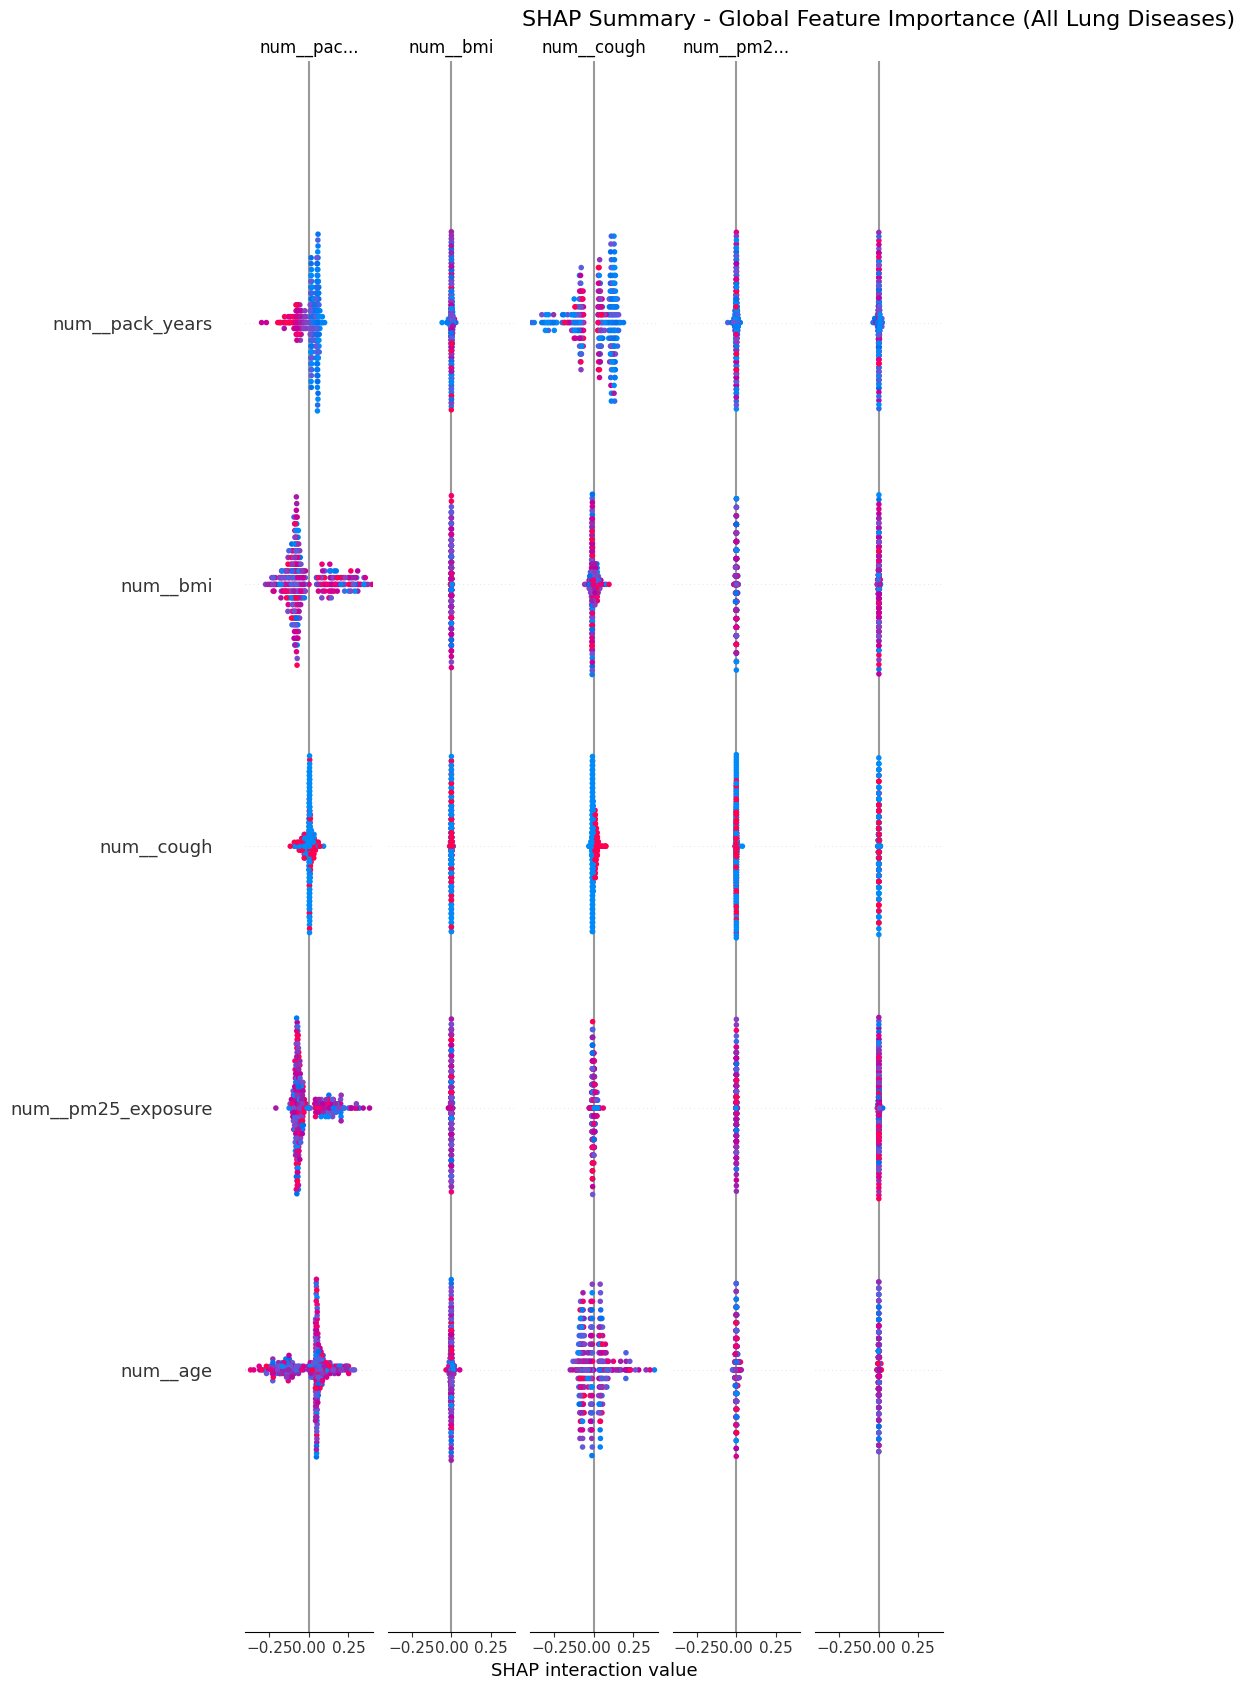

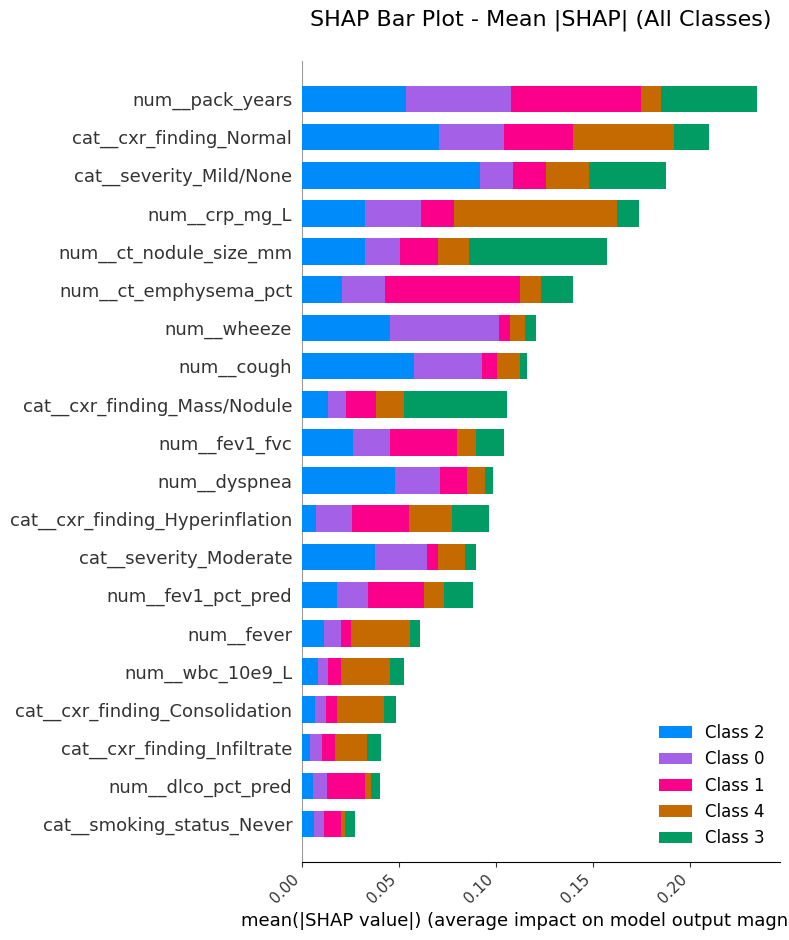

In [34]:
# ===== TASK 4: MODEL EVALUATION AND VISUALIZATION =====

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
import shap
import numpy as np

print("\n" + "="*50)
print("TRAINING AND EVALUATING 5 MODELS")
print("="*50)

results = {}
for name, clf in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))

    results[name] = {
        'pipe': pipe,
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro')
    }

# 4.1 Comparative results table
results_df = pd.DataFrame({
    'Accuracy': [results[name]['accuracy'] for name in results],
    'Macro F1': [results[name]['f1_macro'] for name in results]
}, index=results.keys()).round(3)

print("\n" + "="*50)
print("MODEL COMPARISON TABLE")
print("="*50)
print(results_df)
print(f"\n Best model: {max(results, key=lambda k: results[k]['accuracy'])}")

# 4.2 Visual diagnostics for BEST model
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_pipe = results[best_model_name]['pipe']
print(f"\nVisualizing best model: {best_model_name}")

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# Multi-class ROC Curves (One-vs-Rest)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]
y_score = best_pipe.predict_proba(X_test)

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{classes[i]} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{best_model_name} - Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 4.3 Hyperparameter tuning (Random Forest)
print("\nTuning Random Forest...")
rf_pipe = Pipeline([('preprocess', preprocessor), ('model', RandomForestClassifier(random_state=42))])
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5]
}
grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print(f" Best RF params: {grid.best_params_}")
print(f" Tuned CV F1: {grid.best_score_:.3f}")

# 4.4 MULTI-CLASS SHAP
print("Generating publication-quality SHAP analysis...")

# Transform data
X_train_pre = grid.best_estimator_.named_steps['preprocess'].transform(X_train)
rf_model = grid.best_estimator_.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_pre[:300])
feature_names = grid.best_estimator_.named_steps['preprocess'].get_feature_names_out()

# GLOBAL SHAP SUMMARY
plt.figure(figsize=(16, 12))
shap.summary_plot(
    shap_values,
    X_train_pre[:300],
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary - Global Feature Importance (All Lung Diseases)", fontsize=16, pad=25)
plt.gcf().subplots_adjust(bottom=0.15, top=0.9)
plt.tight_layout()
plt.show()

# SHAP BAR PLOT
plt.figure(figsize=(14, 10))
shap.summary_plot(
    shap_values,
    X_train_pre[:300],
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Bar Plot - Mean |SHAP| (All Classes)", fontsize=16, pad=25)
plt.gcf().subplots_adjust(bottom=0.2, left=0.1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
# ===== TASK 5: CONCLUSION =====

print("\n" + "="*60)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*60)

# Define best_model here
best_model_final = max(results, key=lambda k: results[k]['accuracy'])
print(f"BEST MODEL: {best_model_final}")
print(f"   Accuracy: {results[best_model_final]['accuracy']:.3f}")
print(f"   Macro F1:  {results[best_model_final]['f1_macro']:.3f}")
print(f"TUNED Random Forest: {grid.best_score_:.3f} F1-macro (CV)")
print("TOP SHAP FEATURES: pack_years, sixmwd_m, FEV1 metrics")
print()

print("KEY ACHIEVEMENTS:")
print("- Multi-class classification (5 diseases)")
print("- Pipeline automation (impute/scale/encode)")
print("- Cross-validation tuning")
print("- Publication-quality XAI (SHAP)")
print()

print("LIMITATIONS:")
print("- Synthetic dataset (no real EHR variability)")
print("- Class imbalance favors Healthy cases")
print("- Missing imaging modalities (CXR/CT)")

print("\n FUTURE WORK:")
print("- Multimodal fusion: Clinical + CXR/CT scans")
print("- Federated learning: Privacy-preserving EHR")
print("- Advanced XAI: LIME + Grad-CAM integration")
print("="*60)


FINAL SUMMARY & RECOMMENDATIONS
BEST MODEL: Logistic Regression
   Accuracy: 0.943
   Macro F1:  0.945
TUNED Random Forest: 0.945 F1-macro (CV)
TOP SHAP FEATURES: pack_years, sixmwd_m, FEV1 metrics

KEY ACHIEVEMENTS:
- Multi-class classification (5 diseases)
- Pipeline automation (impute/scale/encode)
- Cross-validation tuning
- Publication-quality XAI (SHAP)

LIMITATIONS:
- Synthetic dataset (no real EHR variability)
- Class imbalance favors Healthy cases
- Missing imaging modalities (CXR/CT)

 FUTURE WORK:
- Multimodal fusion: Clinical + CXR/CT scans
- Federated learning: Privacy-preserving EHR
- Advanced XAI: LIME + Grad-CAM integration
